
Dataset Loaded Successfully!

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  price
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556  4.526
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842  3.585
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260  3.521
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945  3.413
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467  3.422


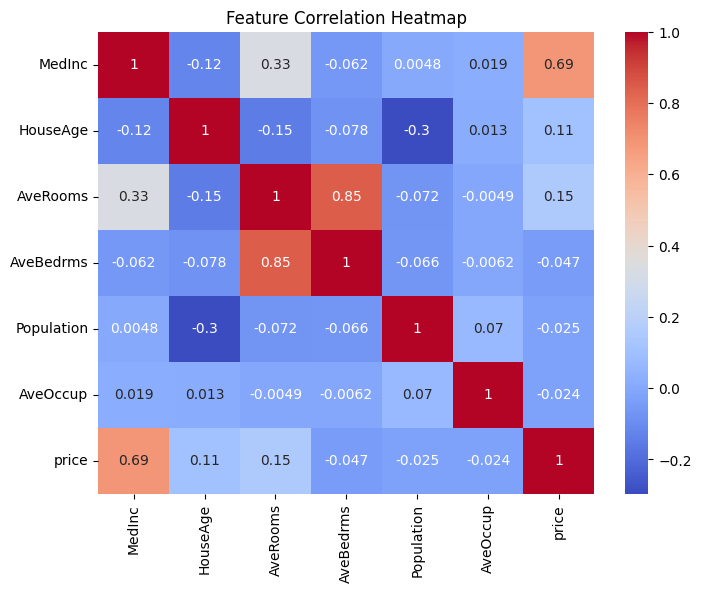


Model Trained Successfully!

Training R2 Score: 0.862553151879597
Test R2 Score: 0.6779798373835135
Training MAE: 0.3157165082681685
Test MAE: 0.470144408995784


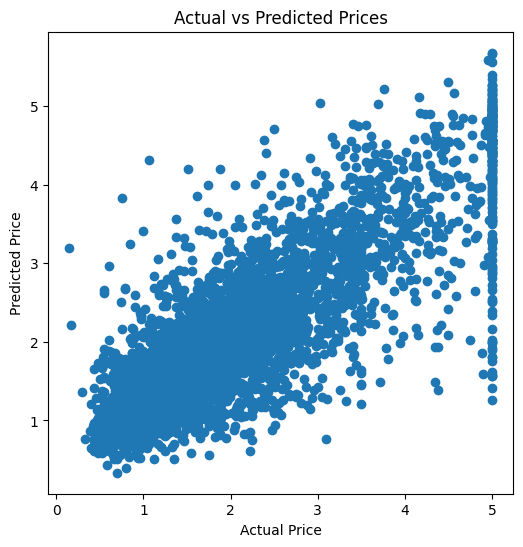


===== Enter Details for Prediction =====
Median Income (Example: 3.5): 6
House Age (Example: 25): 3
Average Rooms (Example: 5): 2
Average Bedrooms (Example: 1): 1
Population (Example: 1000): 4
Average Occupancy (Example: 3): 3

🏠 Predicted House Price: 2.0307736
👉 Multiply by 100000 for actual price


In [1]:
# ============================================
# House Price Prediction (Simplified Version)
# No Latitude & Longitude + With Graphs
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

# ============================================
# 1. Load Dataset
# ============================================

data = sklearn.datasets.fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)

# Drop Latitude & Longitude
df = df.drop(['Latitude', 'Longitude'], axis=1)

# Add target
df['price'] = data.target

print("\nDataset Loaded Successfully!\n")
print(df.head())

# ============================================
# 2. Correlation Heatmap
# ============================================

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# ============================================
# 3. Split Data
# ============================================

X = df.drop('price', axis=1)
Y = df['price']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2
)

# ============================================
# 4. Train Model
# ============================================

model = XGBRegressor()
model.fit(X_train, Y_train)

print("\nModel Trained Successfully!\n")

# ============================================
# 5. Evaluation
# ============================================

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Training R2 Score:", metrics.r2_score(Y_train, train_pred))
print("Test R2 Score:", metrics.r2_score(Y_test, test_pred))

print("Training MAE:", metrics.mean_absolute_error(Y_train, train_pred))
print("Test MAE:", metrics.mean_absolute_error(Y_test, test_pred))

# ============================================
# 6. Graph: Actual vs Predicted
# ============================================

plt.figure(figsize=(6,6))
plt.scatter(Y_test, test_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

# ============================================
# 7. User Input
# ============================================

print("\n===== Enter Details for Prediction =====")

try:
    MedInc = float(input("Median Income (Example: 3.5): "))
    HouseAge = float(input("House Age (Example: 25): "))
    AveRooms = float(input("Average Rooms (Example: 5): "))
    AveBedrms = float(input("Average Bedrooms (Example: 1): "))
    Population = float(input("Population (Example: 1000): "))
    AveOccup = float(input("Average Occupancy (Example: 3): "))

    input_data = np.array([[MedInc, HouseAge, AveRooms,
                            AveBedrms, Population, AveOccup]])

    prediction = model.predict(input_data)

    print("\n🏠 Predicted House Price:", prediction[0])
    print("👉 Multiply by 100000 for actual price")

except ValueError:
    print("❌ Please enter valid numeric values!")